In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
path= '/content/drive/MyDrive/thesis/code'
os.chdir(path)
import sys

Mounted at /content/drive


In [51]:
# -*- coding: utf-8 -*-
"""Self Accuracy vs Model Size Analysis"""

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rationale_benchmark.utils import load_documents, annotations_from_jsonl
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

class ModelAnalyzer:
    def __init__(self, base_path):
        self.base_path = base_path
        self.results = {}

    def analyze_dataset(self, dataset_name, models, attack_suffix="TextFoolerJin2019.csv"):
        """Analyze a dataset for multiple models"""
        print(f"\n{'='*50}")
        print(f"Analyzing {dataset_name.upper()} dataset")
        print(f"{'='*50}")

        # Load dataset specific data
        if dataset_name == 'movies':
            data_root = os.path.join(self.base_path, 'eraserbenchmark-master/data/movies')
            documents = load_documents(data_root)
            annotations = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
            label_mapping = lambda x: 'negative' if x.annotation_id[0] == 'n' else 'positive'

        elif dataset_name == 'esnli':
            data_root = os.path.join(self.base_path, 'eraserbenchmark-master/data/esnli')
            documents = load_documents(data_root)
            annotations = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
            annotations = [inst for inst in annotations if inst.classification in ('entailment', 'contradiction')]
            label_mapping = lambda x: 'no' if x.classification == 'contradiction' else 'yes'

        dataset_results = {}

        for model in models:
            print(f"\nAnalyzing {model}...")

            # Load counterfactual analysis data
            if 'Llama' in model:
                cf_path = os.path.join(self.base_path, f"introspections/{dataset_name}_introspections/{model}/results/analysis")
                cf_file = "analysis_m-llama3_y-none_d-imdb_p-test_t-counterfactual_c-_s-0.sqlite" if dataset_name == 'movies' else "analysis_m-llama3_y-none_d-rte_p-test_t-counterfactual_c-_s-0.sqlite"
            else:  # Qwen models
                cf_path = os.path.join(self.base_path, f"introspections/{dataset_name}_introspections/{model}/results/analysis")
                cf_file = "analysis_m-qwen_y-none_d-imdb_p-test_t-counterfactual_c-_s-0.sqlite" if dataset_name == 'movies' else "analysis_m-qwen_y-none_d-rte_p-test_t-counterfactual_c-_s-0.sqlite"

            conn = sqlite3.connect(os.path.join(cf_path, cf_file))
            df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)
            conn.close()

            # Load attack data
            attack_path = os.path.join(self.base_path, f'attacks/{dataset_name}_attacks')
            attack_df = pd.read_csv(os.path.join(attack_path, f"{model}_{attack_suffix}"))

            # Calculate metrics
            metrics = self._calculate_metrics(df, attack_df, annotations, label_mapping)
            dataset_results[model] = metrics

            print(f"  Self Accuracy: {metrics['self_accuracy']:.3f}")
            print(f"  Attack Accuracy: {metrics['attack_accuracy']:.3f}")
            print(f"  Alignment: {metrics['alignment']:.3f}")

        self.results[dataset_name] = dataset_results
        return dataset_results

    def _calculate_metrics(self, cf_df, attack_df, annotations, label_mapping):
        """Calculate performance metrics"""
        aligned = 0
        attack_correct = 0
        self_correct = 0
        total = min(len(cf_df), len(attack_df), len(annotations))

        for i in range(total):
            true_label = label_mapping(annotations[i])

            # Attack accuracy
            if (attack_df.iloc[i]['original_output'] < 0.5 and true_label == 'negative') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and true_label == 'positive') or \
               (attack_df.iloc[i]['original_output'] < 0.5 and true_label == 'no') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and true_label == 'yes'):
                attack_correct += 1

            # Self accuracy
            if cf_df.iloc[i]['predict'] == true_label:
                self_correct += 1

            # Alignment
            if (attack_df.iloc[i]['original_output'] < 0.5 and cf_df.iloc[i]['predict'] == 'negative') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and cf_df.iloc[i]['predict'] == 'positive') or \
               (attack_df.iloc[i]['original_output'] < 0.5 and cf_df.iloc[i]['predict'] == 'no') or \
               (attack_df.iloc[i]['original_output'] > 0.5 and cf_df.iloc[i]['predict'] == 'yes'):
                aligned += 1

        return {
            'self_accuracy': self_correct / total,
            'attack_accuracy': attack_correct / total,
            'alignment': aligned / total,
            'total_samples': total
        }

    def plot_accuracy_vs_size(self, save_path=None):
        """Plot accuracy vs model size for both datasets"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Accuracy vs Model Size', fontsize=16, fontweight='bold')

        # Model size mapping
        size_mapping = {
            '1.5B': 1.5, '1B': 1.0, '3B': 3.0, '3.2-3B': 3.0,
            '7B': 7.0, '8B': 8.0
        }

        # Plot for Movies dataset
        movies_results = self.results.get('movies', {})

        # Llama models for movies
        llama_sizes = []
        llama_accuracies = []

        for model, metrics in movies_results.items():
            if 'Llama' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        llama_sizes.append(size)
                        llama_accuracies.append(metrics['self_accuracy'])
                        break

        if llama_sizes:
            sorted_data = sorted(zip(llama_sizes, llama_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax1.plot(sizes, accuracies, 'o-', linewidth=3, markersize=10,
                    label='Llama', color='skyblue', markerfacecolor='blue', markeredgecolor='black')

        # Qwen models for movies
        qwen_sizes = []
        qwen_accuracies = []

        for model, metrics in movies_results.items():
            if 'Qwen' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        qwen_sizes.append(size)
                        qwen_accuracies.append(metrics['self_accuracy'])
                        break

        if qwen_sizes:
            sorted_data = sorted(zip(qwen_sizes, qwen_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax1.plot(sizes, accuracies, 's-', linewidth=3, markersize=10,
                    label='Qwen', color='lightcoral', markerfacecolor='red', markeredgecolor='black')

        ax1.set_title('Movies Dataset', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Model Size (Billion Parameters)', fontsize=12)
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)
        ax1.set_ylim(0, 1)

        # Plot for e-SNLI dataset
        esnli_results = self.results.get('esnli', {})

        # Llama models for e-SNLI
        llama_sizes = []
        llama_accuracies = []

        for model, metrics in esnli_results.items():
            if 'Llama' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        llama_sizes.append(size)
                        llama_accuracies.append(metrics['self_accuracy'])
                        break

        if llama_sizes:
            sorted_data = sorted(zip(llama_sizes, llama_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax2.plot(sizes, accuracies, 'o-', linewidth=3, markersize=10,
                    label='Llama', color='skyblue', markerfacecolor='blue', markeredgecolor='black')

        # Qwen models for e-SNLI
        qwen_sizes = []
        qwen_accuracies = []

        for model, metrics in esnli_results.items():
            if 'Qwen' in model:
                for key, size in size_mapping.items():
                    if key in model:
                        qwen_sizes.append(size)
                        qwen_accuracies.append(metrics['self_accuracy'])
                        break

        if qwen_sizes:
            sorted_data = sorted(zip(qwen_sizes, qwen_accuracies))
            sizes, accuracies = zip(*sorted_data)
            ax2.plot(sizes, accuracies, 's-', linewidth=3, markersize=10,
                    label='Qwen', color='lightcoral', markerfacecolor='red', markeredgecolor='black')

        ax2.set_title('e-SNLI Dataset', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Model Size (Billion Parameters)', fontsize=12)
        ax2.set_ylabel('Self Accuracy', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)
        ax2.set_ylim(0, 1)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Self accuracy plot saved to {save_path}")

        plt.show()

    def generate_summary_table(self):
        """Generate a summary table of all results"""
        summary_data = []

        for dataset_name, dataset_results in self.results.items():
            for model, metrics in dataset_results.items():
                summary_data.append({
                    'Dataset': dataset_name.upper(),
                    'Model': model,
                    'Self Accuracy': f"{metrics['self_accuracy']:.3f}",
                    'Attack Accuracy': f"{metrics['attack_accuracy']:.3f}",
                    'Alignment': f"{metrics['alignment']:.3f}",
                    'Samples': metrics['total_samples']
                })

        summary_df = pd.DataFrame(summary_data)
        return summary_df


Analyzing MOVIES dataset

Analyzing Llama-3.2-1B-Instruct...
  Self Accuracy: 0.538
  Attack Accuracy: 0.533
  Alignment: 0.985

Analyzing Llama-3.2-3B-Instruct...
  Self Accuracy: 0.905
  Attack Accuracy: 0.905
  Alignment: 0.990

Analyzing Meta-Llama-3-8B-Instruct...
  Self Accuracy: 0.965
  Attack Accuracy: 0.965
  Alignment: 1.000

Analyzing Qwen-1.5B...
  Self Accuracy: 0.915
  Attack Accuracy: 0.920
  Alignment: 0.975

Analyzing Qwen-3B...
  Self Accuracy: 0.859
  Attack Accuracy: 0.854
  Alignment: 0.995

Analyzing Qwen-7B...
  Self Accuracy: 0.940
  Attack Accuracy: 0.940
  Alignment: 1.000

Analyzing ESNLI dataset

Analyzing Llama-3.2-1B-Instruct...
  Self Accuracy: 0.567
  Attack Accuracy: 0.604
  Alignment: 0.867

Analyzing Llama-3.2-3B-Instruct...
  Self Accuracy: 0.745
  Attack Accuracy: 0.730
  Alignment: 0.947

Analyzing Meta-Llama-3-8B-Instruct...
  Self Accuracy: 0.889
  Attack Accuracy: 0.883
  Alignment: 0.972

Analyzing Qwen-1.5B...
  Self Accuracy: 0.847
  Attack 

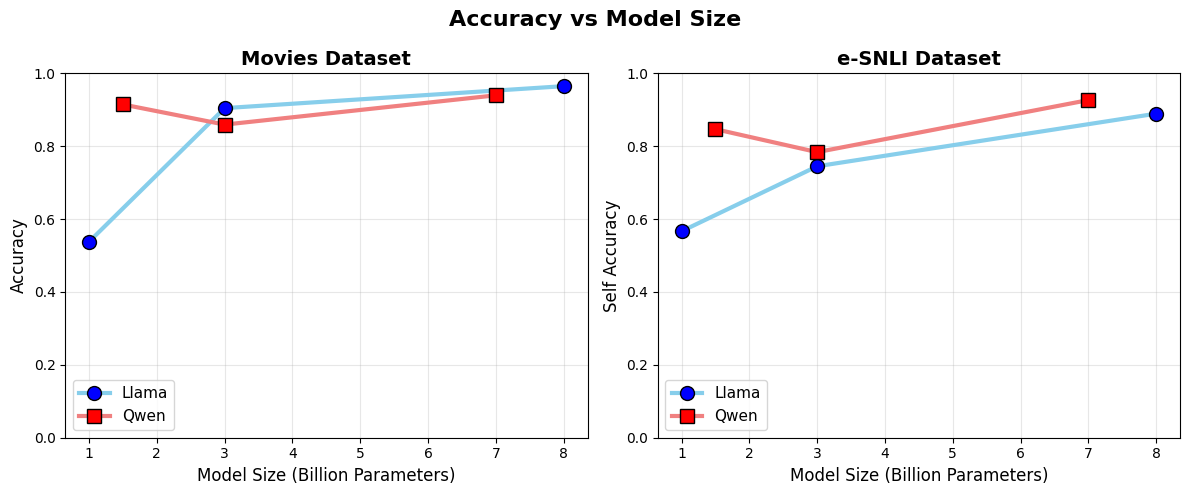


COMPREHENSIVE RESULTS SUMMARY
Dataset                    Model Self Accuracy Attack Accuracy Alignment  Samples
 MOVIES    Llama-3.2-1B-Instruct         0.538           0.533     0.985      199
 MOVIES    Llama-3.2-3B-Instruct         0.905           0.905     0.990      199
 MOVIES Meta-Llama-3-8B-Instruct         0.965           0.965     1.000      199
 MOVIES                Qwen-1.5B         0.915           0.920     0.975      199
 MOVIES                  Qwen-3B         0.859           0.854     0.995      199
 MOVIES                  Qwen-7B         0.940           0.940     1.000      199
  ESNLI    Llama-3.2-1B-Instruct         0.567           0.604     0.867     6598
  ESNLI    Llama-3.2-3B-Instruct         0.745           0.730     0.947     6598
  ESNLI Meta-Llama-3-8B-Instruct         0.889           0.883     0.972     6598
  ESNLI                Qwen-1.5B         0.847           0.888     0.945     6598
  ESNLI                  Qwen-3B         0.784           0.662     

In [53]:
analyzer = ModelAnalyzer(path)

# Define models
llama_models = ['Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct', 'Meta-Llama-3-8B-Instruct']
qwen_models = ['Qwen-1.5B', 'Qwen-3B', 'Qwen-7B']

all_models = llama_models + qwen_models

# Analyze datasets
analyzer.analyze_dataset('movies', all_models)
analyzer.analyze_dataset('esnli', all_models)

# Generate self accuracy vs size plot
analyzer.plot_accuracy_vs_size(save_path='results/classifiers_accuracy_vs_size.png')

# Generate summary table (for alignment information)
summary_df = analyzer.generate_summary_table()
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))